### ICTV taxonomy of CF virome

In [1]:
### load packages
import gzip

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

In [2]:
### Identify viruses detected in CF metagenomes
activity_data = (
    pl.read_csv('cf_metagenome_virus_activity_data.tsv', separator='\t')
        .filter(pl.col('breadth_ratio') >= 0.6)
)

In [3]:
activity_data.height

50482

In [4]:
pl.read_parquet('../figure_4/uhvdb_r2025_10_v_VMR_MSL40.v2.20251013.parquet').filter(pl.col('column_1').str.contains('SAMN16578693.contig00006')).filter(pl.col('column_3') >= 5.5).sort(pl.col('column_3'), descending=True)

column_1,column_2,column_3
str,str,f64
"""SAMN16578693.contig00006|provi…","""Primolicivirus_Pf8--MN710383.1""",17.23
"""SAMN16578693.contig00006|provi…","""Felsduovirus_Fels2--AE006468.2""",14.92
"""SAMN16578693.contig00006|provi…","""Citexvirus_PS75V--KK213166.1""",13.14
"""SAMN16578693.contig00006|provi…","""Citexvirus_phiCTX--AB008550.1""",12.99
"""SAMN16578693.contig00006|provi…","""Citexvirus_BR319A--MK511066.1""",12.98
…,…,…
"""SAMN16578693.contig00006|provi…","""Nampongvirus_ST79--KC462197.1""",5.88
"""SAMN16578693.contig00006|provi…","""Tigrvirus_phiE094--MW072790.1""",5.87
"""SAMN16578693.contig00006|provi…","""Kayeltresvirus_menos--OM638610…",5.87


In [5]:
### extract protein similarity to ICTV for CF viruses
cf_proteinsim = (
    pl.read_parquet('../figure_4/uhvdb_r2025_10_v_VMR_MSL40.v2.20251013.parquet')
        .filter(pl.col('column_3') >= 5.5)
        .sort('column_3', descending=True)
        .unique('column_1', keep='first', maintain_order=True)
        .join(activity_data, left_on='column_1', right_on='contig_id', how='right')
)

print("Number of CF viruses with a hit to ICTV:",
    cf_proteinsim.unique(['contig_id', 'sample_id']).height
)

Number of CF viruses with a hit to ICTV: 50482


In [6]:
### Count number of queries with family, subfamily, genus, subgenus, species level hits
print("Number of CF viruses with family hit to ICTV:",
    cf_proteinsim.filter(pl.col('column_3') >= 5.5).unique(['contig_id', 'sample_id']).height
)

print("Number of CF viruses with subfamily hit to ICTV:",
    cf_proteinsim.filter(pl.col('column_3') >= 32).unique(['contig_id', 'sample_id']).height
)

print("Number of CF viruses with genus hit to ICTV:",
    cf_proteinsim.filter(pl.col('column_3') >= 65).unique(['contig_id', 'sample_id']).height
)

print("Number of CF viruses with subgenus hit to ICTV:",
    cf_proteinsim.filter(pl.col('column_3') >= 80).unique(['contig_id', 'sample_id']).height
)

print("Number of CF viruses with species hit to ICTV:",
    cf_proteinsim.filter(pl.col('column_3') >= 95).unique(['contig_id', 'sample_id']).height
)

Number of CF viruses with family hit to ICTV: 36705
Number of CF viruses with subfamily hit to ICTV: 6130
Number of CF viruses with genus hit to ICTV: 1535
Number of CF viruses with subgenus hit to ICTV: 610
Number of CF viruses with species hit to ICTV: 212


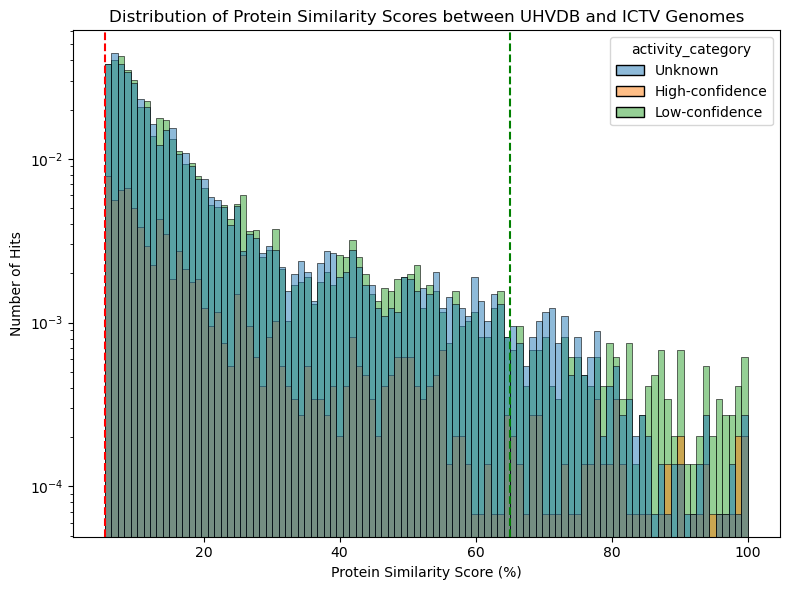

In [7]:
plot_df = (
    cf_proteinsim
        .with_columns([
            pl.when(pl.col('activity_score') >= 3).then(pl.lit('High-confidence'))
            .when(pl.col('activity_score') >= 1).then(pl.lit('Low-confidence'))
            .otherwise(pl.lit('Unknown'))
            .alias('activity_category')
        ])
        .sort(pl.col('column_3'), descending=True)
        .unique(['contig_id', 'sample_id'], maintain_order=True)
)

# create histogram of protein similarity scores with proportions by activity category
plt.figure(figsize=(8,6))
sns.histplot(data=plot_df.group_by(['contig_id', 'activity_category']).agg([pl.col('column_3').max().alias('max_similarity')]), x='max_similarity', hue='activity_category', bins=100, stat='probability')
plt.xlabel('Protein Similarity Score (%)')
plt.ylabel('Number of Hits')
plt.yscale('log')
plt.title('Distribution of Protein Similarity Scores between UHVDB and ICTV Genomes')
plt.axvline(x=5.5, color='red', linestyle='--', label='Family Level Threshold (5.5%)')
plt.axvline(x=65, color='green', linestyle='--', label='Genus Level Threshold (65%)')
# plt.legend()
plt.tight_layout()
plt.show()

In [8]:
### read ICTV taxonomic assignments
msl40 = pl.read_excel('../figure_s12/VMR_MSL40.v2.20251013.xlsx', sheet_name='VMR MSL40')

Could not determine dtype for column 4, falling back to string
Could not determine dtype for column 6, falling back to string
Could not determine dtype for column 8, falling back to string
Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 12, falling back to string
Could not determine dtype for column 16, falling back to string


In [9]:
### Determine the most prevalent families among ICTV hits
family_hits = (
    plot_df
        .sort(pl.col('column_3'), descending=True)
        .unique(['contig_id', 'sample_id', 'activity_category'])
        .with_columns([
            pl.col('column_2').str.split('--').list[0].str.replace('_', ' ').alias('Species')
        ])
)

family_hits_msl40 = (
    msl40.unique('Species').join(family_hits, on='Species', how='right')
        .with_columns([
            pl.when((pl.col('Family').is_null()) & (pl.col('Class') == 'Caudoviricetes')).then(pl.lit('Unclassified Caudoviricetes'))
                .when(pl.col('Family').is_null()).then(pl.lit('No family assignment'))
                .otherwise(pl.col('Family')).alias('Family')
        ])
)

### most prevalent families for all CF viruses
print("Number of CF viruses with family level hits to ICTV:", family_hits_msl40.filter(pl.col('activity_category') == 'Unknown').height)
family_hits_msl40.filter(pl.col('activity_category') == 'Unknown').group_by('Family').len().sort('len', descending=True).head(10)

Number of CF viruses with family level hits to ICTV: 22811


Family,len
str,u32
"""Unclassified Caudoviricetes""",10730
"""No family assignment""",6193
"""Peduoviridae""",1507
"""Aliceevansviridae""",852
"""Inoviridae""",724
"""Alisviridae""",520
"""Rhodogtaviriformidae""",491
"""Nixviridae""",404
"""Winoviridae""",205


In [10]:
family_hits_msl40.write_csv('cf_viruses_ictv_family_hits.tsv', separator='\t')

In [11]:
### most prevalent families for all CF viruses with high activity
print("Number of active CF viruses with family level hits to ICTV:", family_hits_msl40.filter(pl.col('activity_category') == 'High-confidence').height)
family_hits_msl40.filter(pl.col('activity_category') == 'High-confidence').group_by('Family').len().sort('len', descending=True).head(10)

Number of active CF viruses with family level hits to ICTV: 3427


Family,len
str,u32
"""Unclassified Caudoviricetes""",1445
"""No family assignment""",1081
"""Peduoviridae""",187
"""Aliceevansviridae""",178
"""Inoviridae""",170
"""Chimalliviridae""",34
"""Rhodogtaviriformidae""",28
"""Orlajensenviridae""",28
"""Intestiviridae""",24


/tmp/ipykernel_31460/66418846.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([
/tmp/ipykernel_31460/66418846.py:20: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index='activity_category', columns='ICTV Family', values='len', aggregate_function='sum')


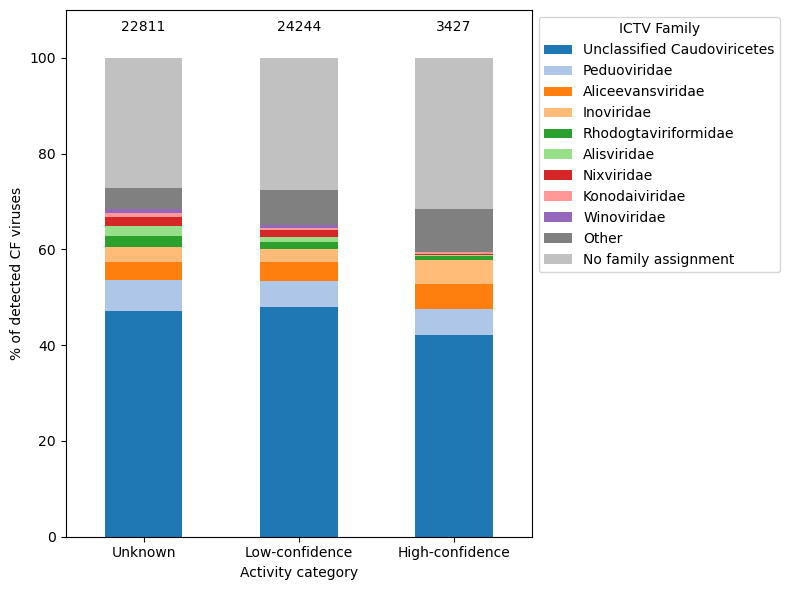

In [12]:
# Get top 10 families overall
top_families = family_hits_msl40.filter(pl.col('activity_category') == 'Unknown').group_by('Family').len().sort('len', descending=True).head(10)['Family']

# Classify families as top 10 or "Other"
family_hits_classified = (
    family_hits_msl40
        .with_columns([
            pl.when(pl.col('Family').is_in(top_families))
                .then(pl.col('Family'))
                .otherwise(pl.lit('Other'))
                .alias('Family_classified')
        ])
        .rename({'Family_classified': 'ICTV Family'})
)

family_by_site = (
    family_hits_classified
        .group_by(['activity_category', 'ICTV Family'])
        .len()
        .pivot(index='activity_category', columns='ICTV Family', values='len', aggregate_function='sum')
        .fill_null(0)
)

# Convert to pandas for easier manipulation
family_by_site_pd = family_by_site.to_pandas().set_index('activity_category')

# Calculate total counts per body site
totals = family_by_site_pd.sum(axis=1)

# Calculate proportions (normalize to 100%)
family_proportions = family_by_site_pd.div(totals, axis=0) * 100

# Order families by average abundance (greatest to least, excluding Other and No family assignment)
family_avg = family_proportions.mean().sort_values(ascending=False)
# Remove 'Other' and 'No family assignment' from ordering
exclude_cols = []
if 'Other' in family_avg.index:
    exclude_cols.append('Other')
if 'No family assignment' in family_avg.index:
    exclude_cols.append('No family assignment')

family_avg_filtered = family_avg.drop(exclude_cols) if exclude_cols else family_avg
# Order: highest abundance at bottom (first), lowest at top, Other, then No family assignment at very top
ordered_cols = family_avg_filtered.sort_values(ascending=False).index.tolist()
if 'Other' in family_avg.index:
    ordered_cols.append('Other')
if 'No family assignment' in family_avg.index:
    ordered_cols.append('No family assignment')

family_proportions = family_proportions[ordered_cols]

# Create custom color palette - use default colors for families, grey for Other, white for No family assignment
import matplotlib.cm as cm
n_families = len(family_proportions.columns)
# Subtract special categories from color count
if 'Other' in family_proportions.columns:
    n_families -= 1
if 'No family assignment' in family_proportions.columns:
    n_families -= 1

colors = list(plt.cm.tab20.colors[:n_families])
if 'Other' in family_proportions.columns:
    colors.append('#808080')  # Add grey for Other
if 'No family assignment' in family_proportions.columns:
    colors.append('#C1C1C1')  # Add white for No family assignment

# Create stacked bar chart with proportions
# order of x-axis categories
activity_order = ['Unknown', 'Low-confidence', 'High-confidence']
family_proportions = family_proportions.reindex(activity_order)
ax = family_proportions.plot(kind='bar', stacked=True, figsize=(8, 6), color=colors)
# make x-axis tick labels horizontal
plt.xticks(rotation=0)
plt.xlabel('Activity category')
plt.ylabel('% of detected CF viruses')
plt.legend(title='ICTV Family', bbox_to_anchor=(1.0, 1), loc='upper left')

# Add total counts above each bar
for i, total in enumerate(totals.reindex(activity_order)):
    ax.text(i, 105, str(total), ha='center', va='bottom', fontsize=10)

plt.ylim(0, 110)  # Make room for the count labels
plt.tight_layout()
plt.show()

In [13]:
high_prev = set(pl.read_csv('high_prev_cf_viruses.tsv', separator='\t')['contig_id'])

family_hits_msl40.rename({'column_3': 'protein_similarity'}).filter(pl.col('contig_id').is_in(high_prev))[['Family', 'Class', 'Realm', 'protein_similarity', 'Virus name(s)', 'contig_id']].unique('contig_id')#.write_csv('high_prev_cf_virus_family.tsv', separator='\t')

Family,Class,Realm,protein_similarity,Virus name(s),contig_id
str,str,str,f64,str,str
"""Kanorauviridae""","""Arfiviricetes""","""Monodnaviria""",8.48,"""sewage-associated circular DNA…","""SAMN40993948_SRR28721147_cf_k2…"
"""Unclassified Caudoviricetes""","""Caudoviricetes""","""Duplodnaviria""",36.27,"""Streptococcus phage IPP61""","""SAMEA110349439.contig00009|pro…"
"""Rhodogtaviriformidae""",null,null,14.21,"""Rhodobacter capsulatus gene tr…","""SAMEA10741205_k141_41777"""
"""Unclassified Caudoviricetes""","""Caudoviricetes""","""Duplodnaviria""",13.03,"""Streptococcus phage OlisA1""","""ERZ21615859.50|provirus_3_5284…"
"""Peduoviridae""","""Caudoviricetes""","""Duplodnaviria""",10.9,"""Salmonella phage Fels2""","""ERZ21615758.302"""
"""Inoviridae""","""Faserviricetes""","""Monodnaviria""",17.23,"""Pseudomonas phage pf8_ST274-AU…","""SAMN16578693.contig00006|provi…"


In [15]:
high_cov = set(pl.read_csv('cf_pathogen_cov_active.tsv', separator='\t')['contig_id'])

family_hits_msl40.rename({'column_3': 'protein_similarity'}).filter(pl.col('contig_id').is_in(high_cov))[['Family', 'Class', 'Realm', 'protein_similarity', 'Virus name(s)', 'contig_id']].unique('contig_id').write_csv('high_cov_cf_virus_family.tsv', separator='\t')

In [29]:
pl.read_csv('cf_pathogen_cov_active.tsv', separator='\t').filter(pl.col('genus') == 'g__Pseudomonas')

contig_id,sample_id,bioproject,num_bp,breadth_score,ref_dtr_score,ref_virulent_score,trimmed_mean,mean,breadth,breadth_ratio,True_cov_virus,completeness_method,virulent,dtr_score,num_oprs,num_clipped,CohenD,prophage-host_ratio,mvirs_score,propagate_score,activity_score,reference_activity_score,genome_id,genus,True_cov,Sequence_abundance,virus_to_host,activity_status,ratio_cat
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,str,str
"""SAMN16789143.contig00012|provi…","""SAMN28534933_SRR19277166_cf""","""prjna839435""",27066588,0.0,0.0,0.0,2.3122113,2.6304495,0.552549,0.62209,3.88,"""AAI-based (high-confidence)""",0.0,0.0,null,null,null,null,0.0,0.0,0.0,0.0,"""GCF_001457615""","""g__Pseudomonas""",1.731,69.8554,2.241479,"""activity unknown""","""cov active"""
"""SAMN46278844.contig00008|provi…","""SAMN40589479_SRR28442020_cf""","""prjna1091195""",277595488,0.0,0.0,0.0,32.60439,34.084778,0.7647,0.7647,33.572,"""AAI-based (medium-confidence)""",0.0,0.0,null,null,1.965465,2.145507,0.0,3.0,3.0,0.0,"""GCF_001457615""","""g__Pseudomonas""",16.486,61.8973,2.036395,"""hc active""","""cov active"""
"""SAMEA104128203.contig00044""","""SAMN11135522_SRR8731656_cf""","""prjna516442""",39740273,0.0,0.0,0.0,5.6594133,5.925821,0.645116,0.649783,11.044,"""AAI-based (high-confidence)""",0.832544,0.0,null,null,null,null,0.0,0.0,0.0,0.0,"""GCF_001457615""","""g__Pseudomonas""",4.448,77.8947,2.482914,"""activity unknown""","""cov active"""
"""SAMEA6262285.contig00027""","""SAMN10805721_SRR8482160_cf""","""prjna516870""",66364835,0.0,0.0,0.0,10.044753,10.500568,0.791807,0.791933,21.074,"""AAI-based (high-confidence)""",0.0125,0.0,null,null,null,null,0.0,0.0,0.0,0.0,"""GCF_001457615""","""g__Pseudomonas""",9.008,85.8798,2.339476,"""activity unknown""","""cov active"""
"""SAMN10805725_SRR8482123_cf_k25…","""SAMN10805725_SRR8482123_cf""","""prjna516870""",94337826,1.0,0.0,0.0,226.27611,227.95064,1.0,1.0,222.24,"""AAI-based (high-confidence)""",0.0125,0.0,14,1,null,null,3.0,0.0,4.0,1.0,"""GCF_001457615""","""g__Pseudomonas""",11.751,77.7106,18.912433,"""hc active""","""cov active"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SAMN47245811.contig00105""","""SAMEA110233648_ERR9902056_cf""","""prjeb54014""",46719798,1.0,0.0,0.0,14.95811,15.260477,0.9841,0.984103,17.128,"""AAI-based (high-confidence)""",0.820044,0.0,null,null,null,null,0.0,0.0,1.0,1.0,"""GCF_001457615""","""g__Pseudomonas""",4.518,84.0146,3.791058,"""lc active""","""cov active"""
"""SRR8731681_141_11682_round8-12…","""SAMN11135570_SRR8731686_cf""","""prjna516442""",10452636,1.0,1.0,0.0,2.7497568,2.8255997,0.915718,1.011859,3.284,"""DTR (high-confidence)""",0.1625,0.0,null,null,null,null,0.0,0.0,2.0,2.0,"""GCF_001457615""","""g__Pseudomonas""",1.471,93.5511,2.232495,"""lc active""","""cov active"""
"""SAMN38342500.contig00061""","""SAMN10805700_SRR8482178_cf""","""prjna516870""",190059623,0.0,0.0,0.0,32.79209,33.39494,0.761769,0.761769,44.469,"""AAI-based (high-confidence)""",0.85,0.0,null,null,null,null,0.0,0.0,0.0,0.0,"""GCF_001457615""","""g__Pseudomonas""",19.043,72.756,2.335189,"""activity unknown""","""cov active"""


In [30]:
high_cov_pa = pl.read_csv('cf_pathogen_cov_active.tsv', separator='\t').filter(pl.col('genus') == 'g__Pseudomonas')
(
    family_hits_msl40
        .unique('contig_id')
        .join(high_cov_pa, on='contig_id', how='inner')
        .group_by('Family')
        .len()
)

Family,len
str,u32
"""No family assignment""",5
"""Peduoviridae""",1
"""Inoviridae""",14
"""Unclassified Caudoviricetes""",12
